# Prédiction du `coordination_risk` dans les topics Gerrit

Nouvelle définition du target (remplace `target_is_bottleneck` du notebook précédent) :

```
coordination_risk(X) = 1  SI  graph_in_degree(X) est eleve            (percentile 75)
                        ET (first_review_delay_hours(X) est eleve     (percentile 75)
                            OU time_open_hours(X) est eleve)          (percentile 75)
                        ET status(X) != MERGED
                       = 0  sinon
```

**Ce que ça capture** : pas juste "beaucoup de changes dependent de moi" (centralite
structurelle), mais un vrai signal de souffrance — un change tres attendu (in_degree
eleve) qui EN PLUS traine en review ou reste ouvert longtemps, et n'est pas resolu.

**⚠️ Consequence anti-leakage** : `graph_in_degree`, `first_review_delay_hours`,
`time_open_hours` et `status` servent tous a definir le target -> ils sont EXCLUS des
features (X). C'est plus de colonnes exclues que dans la version precedente
(`target_is_bottleneck`), donc un jeu de features plus restreint — c'est le prix a payer
pour un label plus riche.

**Cadrage a retenir pour le rapport** : cette definition est plus proche d'une
*detection de l'etat actuel* (le change a deja des symptomes de retard) que d'une
*prediction precoce* (avant que le retard n'apparaisse). A mentionner explicitement dans
les limites (section 14).


## 1. Imports

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report, average_precision_score, roc_auc_score,
    confusion_matrix, f1_score, precision_recall_curve,
)

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42


## 2. Chargement

In [59]:
INPUT_CSV = "change_level_dataset.csv"  # adapte le chemin si besoin

df = pd.read_csv(INPUT_CSV)
print(df.shape)
df.head()


(83500, 27)


C:\Users\hechem\AppData\Local\Temp\ipykernel_6324\2844489690.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_CSV)


,number,change_id,project,branch,topic,status,created,updated,submitted,work_in_progress,mergeable,node_source,insertions,deletions,total_comment_count,unresolved_comment_count,total_patchsets,n_files_changed,total_messages,n_reviewers,first_review_delay_hours,avg_time_between_patchsets_hours,ci_messages_count,time_open_hours,graph_in_degree,graph_out_degree,target_is_bottleneck
0,970573,Idec1953b8d31ca6e14cb8b4b92247acad2e9fb1e,openstack/watcher-dashboard,master,NaN,ABANDONED,2025-12-11 06:28:08.000000000,2026-07-29 14:39:59.000000000,NaN,False,False,original_enriched,1366,1,27,6,20.0,14.0,90.0,3.0,0.00,50.50,45.0,5528.20,0,1,False
1,991059,I43bf8f575eeb7a026c28140007dc0f0fccdf5144,openstack/keystone,master,osprh-27983/pbkdf2-sha512-iterations,NEW,2026-06-02 10:49:17.000000000,2026-07-31 08:05:32.000000000,NaN,False,True,original_enriched,24,3,5,0,7.0,3.0,27.0,5.0,0.65,231.98,14.0,1413.27,0,1,False
2,997991,If2c66cd35da4a2e0653b1f1f571f732ff454c950,starlingx/update,master,metapackage-upload-to-branch,MERGED,2026-07-20 13:45:35.000000000,2026-07-30 20:20:34.000000000,2026-07-30 20:19:24.000000000,False,False,original_enriched,692,19,55,0,11.0,12.0,34.0,3.0,0.33,24.07,13.0,246.58,0,1,False
3,995695,Id364cd25a29aeac80ec983cc8bde8f72fe506bcc,openstack/neutron-tempest-plugin,master,NaN,NEW,2026-07-01 14:40:47.000000000,2026-07-31 14:51:21.000000000,NaN,False,True,original_enriched,355,142,5,2,17.0,4.0,35.0,2.0,1.04,44.74,16.0,720.18,0,1,False
4,993761,I426f46458fbe484afd32e3535c5774a8dbab92c8,starlingx/ansible-playbooks,master,storage-metadata-conflicts,MERGED,2026-06-17 14:32:09.000000000,2026-07-30 12:30:35.000000000,2026-07-30 12:30:35.000000000,False,False,original_enriched,302,6,13,0,19.0,2.0,53.0,4.0,0.09,54.67,16.0,1029.97,0,1,False


In [60]:
df.isna().sum().sort_values(ascending=False)


avg_time_between_patchsets_hours    27784
submitted                           19087
topic                               15029
created                              3239
work_in_progress                     3239
first_review_delay_hours              627
total_patchsets                         1
total_messages                          1
n_files_changed                         1
n_reviewers                             1
ci_messages_count                       1
time_open_hours                         1
mergeable                               0
branch                                  0
updated                                 0
change_id                               0
number                                  0
project                                 0
status                                  0
unresolved_comment_count                0
insertions                              0
deletions                               0
total_comment_count                     0
node_source                       

## 3. Nettoyage

In [61]:
for col in ['work_in_progress', 'mergeable']:
    if df[col].dtype == object:
        df[col] = df[col].map({'True': 1, 'False': 0, True: 1, False: 0})
    df[col] = df[col].fillna(0).astype(int)

# Réduction de cardinalité pour 'project'
TOP_N_PROJECTS = 30
top_projects = df['project'].value_counts().nlargest(TOP_N_PROJECTS).index
df['project'] = df['project'].where(df['project'].isin(top_projects), other='OTHER')

# Valeurs manquantes sur les 2 colonnes utilisees pour le target : NaN -> 0
# (pas de delai mesure = on considere qu'il n'y a pas de signal de retard)
df['first_review_delay_hours'] = df['first_review_delay_hours'].fillna(0)
df['time_open_hours'] = df['time_open_hours'].fillna(0)
df['graph_in_degree'] = df['graph_in_degree'].fillna(0)

df[['project']].value_counts().head(10)


project                         
OTHER                               44245
openstack/tripleo-heat-templates     4208
openstack/project-config             3686
openstack/requirements               2366
openstack/neutron                    2096
openstack/nova                       2003
openstack/devstack                   1540
openstack/openstack-ansible          1468
openstack/puppet-tripleo             1432
starlingx/config                     1300
Name: count, dtype: int64

## 4. Construction du target `coordination_risk`

Les seuils "élevé" sont calculés sur le **train set uniquement**, une fois le split fait
(section 5), pour éviter que la définition du seuil elle-même ne fuite de l'information du
test set. On calcule donc d'abord le split, puis les seuils, puis le label.

## 5. Split train/test par topic

(Avant de définir le target, pour calculer les seuils "élevé" uniquement sur le train.)

In [62]:
def topic_aware_split(df, test_size=0.2, random_state=RANDOM_STATE):
    df = df.copy()
    no_topic_mask = df['topic'].isna()
    df.loc[no_topic_mask, '_split_group'] = [f"__no_topic_{i}" for i in df.index[no_topic_mask]]
    df.loc[~no_topic_mask, '_split_group'] = df.loc[~no_topic_mask, 'topic']

    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, groups=df['_split_group']))
    return df.iloc[train_idx].drop(columns=['_split_group']).copy(), \
           df.iloc[test_idx].drop(columns=['_split_group']).copy()


train_df, test_df = topic_aware_split(df)
print(f"Train : {len(train_df)} lignes | Test : {len(test_df)} lignes")


Train : 66704 lignes | Test : 16796 lignes


In [63]:
# Seuils "eleve" = percentile 75, calcules sur le TRAIN seulement
PCT = 0.75
in_degree_thr = train_df["graph_in_degree"].quantile(PCT)
delay_thr = train_df["first_review_delay_hours"].quantile(PCT)
open_thr = train_df["time_open_hours"].quantile(PCT)

print(f"Seuil graph_in_degree (p{int(PCT*100)})          : {in_degree_thr:.2f}")
print(f"Seuil first_review_delay_hours (p{int(PCT*100)})  : {delay_thr:.2f}")
print(f"Seuil time_open_hours (p{int(PCT*100)})           : {open_thr:.2f}")


def make_coordination_risk(d):
    return (
        (d["graph_in_degree"] >= in_degree_thr) &
        ((d["first_review_delay_hours"] >= delay_thr) | (d["time_open_hours"] >= open_thr)) &
        (d["status"] != "MERGED")
    ).astype(int)


train_df["coordination_risk"] = make_coordination_risk(train_df)
test_df["coordination_risk"] = make_coordination_risk(test_df)

print(f"\nTaux coordination_risk train : {train_df['coordination_risk'].mean():.2%}")
print(f"Taux coordination_risk test  : {test_df['coordination_risk'].mean():.2%}")


Seuil graph_in_degree (p75)          : 1.00
Seuil first_review_delay_hours (p75)  : 1.42
Seuil time_open_hours (p75)           : 795.13

Taux coordination_risk train : 3.93%
Taux coordination_risk test  : 4.14%


## 6. Définition des features (X) — exclusion explicite des colonnes de fuite

In [64]:
LEAKAGE_OR_ID_COLS = [
    'number', 'change_id',
    'graph_in_degree', 'graph_out_degree',       # servent au target (in_degree)
    'first_review_delay_hours', 'time_open_hours',  # servent au target (severite)
    'status',                                     # sert au target (not merged)
    'coordination_risk',
    'target_is_bottleneck',   
]
DATE_COLS = ['created', 'updated', 'submitted']
ID_LIKE_COLS = ['topic', 'node_source', 'project', 'branch']
CATEGORICAL_COLS = []  # 'status' retire (utilise pour le target)

drop_cols = set(LEAKAGE_OR_ID_COLS + DATE_COLS + ID_LIKE_COLS)
feature_cols = [c for c in df.columns if c not in drop_cols]
numeric_cols = [c for c in feature_cols if c not in CATEGORICAL_COLS]

print(f"{len(feature_cols)} features : {feature_cols}")


12 features : ['work_in_progress', 'mergeable', 'insertions', 'deletions', 'total_comment_count', 'unresolved_comment_count', 'total_patchsets', 'n_files_changed', 'total_messages', 'n_reviewers', 'avg_time_between_patchsets_hours', 'ci_messages_count']


In [65]:
X_train, y_train = train_df[feature_cols], train_df['coordination_risk']
X_test, y_test = test_df[feature_cols], test_df['coordination_risk']


## 7. Preprocessing

In [66]:
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])
categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
])


## 8. Entraînement des modèles baseline

In [67]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_true, y_pred, target_names=['not_at_risk', 'coordination_risk']))
    print(f"PR-AUC (average precision) : {average_precision_score(y_true, y_proba):.4f}")
    print(f"ROC-AUC                    : {roc_auc_score(y_true, y_proba):.4f}")
    print(f"F1 (classe coordination_risk) : {f1_score(y_true, y_pred):.4f}")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"Confusion matrix -> TN={tn}  FP={fp}  FN={fn}  TP={tp}")


models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

fitted_pipelines = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    evaluate(name, y_test, y_pred, y_proba)



Logistic Regression
                   precision    recall  f1-score   support

      not_at_risk       0.97      0.83      0.89     16100
coordination_risk       0.09      0.37      0.14       696

         accuracy                           0.81     16796
        macro avg       0.53      0.60      0.52     16796
     weighted avg       0.93      0.81      0.86     16796

PR-AUC (average precision) : 0.0854
ROC-AUC                    : 0.6123
F1 (classe coordination_risk) : 0.1384
Confusion matrix -> TN=13352  FP=2748  FN=440  TP=256

Random Forest
                   precision    recall  f1-score   support

      not_at_risk       0.97      0.95      0.96     16100
coordination_risk       0.21      0.31      0.25       696

         accuracy                           0.92     16796
        macro avg       0.59      0.63      0.61     16796
     weighted avg       0.94      0.92      0.93     16796

PR-AUC (average precision) : 0.1672
ROC-AUC                    : 0.8142
F1 (classe co

## 9. Courbes precision-recall

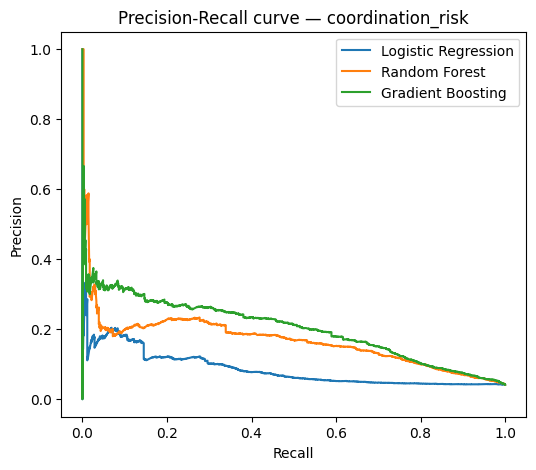

In [68]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, pipe in fitted_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ax.plot(recall, precision, label=name)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curve — coordination_risk')
ax.legend()
plt.show()


## 10. Feature importance (Random Forest)

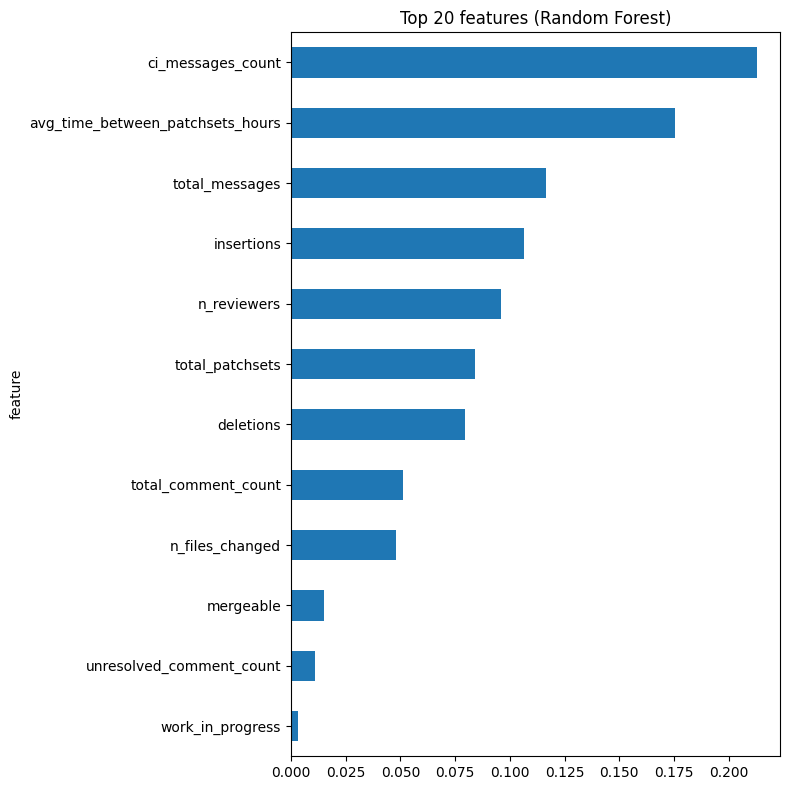

,feature,importance
11,ci_messages_count,0.212808
10,avg_time_between_patchsets_hours,0.175666
8,total_messages,0.116525
2,insertions,0.106542
9,n_reviewers,0.096208
6,total_patchsets,0.084102
3,deletions,0.079501
4,total_comment_count,0.051200
7,n_files_changed,0.048238
1,mergeable,0.015117


In [69]:
rf_pipe = fitted_pipelines['Random Forest']
all_feature_names = numeric_cols
importances = rf_pipe.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

imp_df.plot(kind='barh', x='feature', y='importance', figsize=(8, 8), legend=False)
plt.gca().invert_yaxis()
plt.title('Top 20 features (Random Forest)')
plt.tight_layout()
plt.show()

imp_df


## 11. Réglage du seuil de décision — tous les modèles

In [70]:
def best_threshold_for(pipe, X_te, y_te):
    proba = pipe.predict_proba(X_te)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_te, proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    idx = np.argmax(f1s[:-1])
    return {
        "threshold": thresholds[idx],
        "precision": precisions[idx],
        "recall": recalls[idx],
        "f1": f1s[idx],
        "proba": proba,
    }


threshold_results = {}
for name, pipe in fitted_pipelines.items():
    res = best_threshold_for(pipe, X_test, y_test)
    threshold_results[name] = res

    y_pred_default = pipe.predict(X_test)
    y_pred_tuned = (res["proba"] >= res["threshold"]).astype(int)

    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"Meilleur seuil (max F1) : {res['threshold']:.3f}")
    print(f"  -> precision={res['precision']:.3f}  recall={res['recall']:.3f}  f1={res['f1']:.3f}")
    print(f"F1 avec seuil par defaut (0.5)  : {f1_score(y_test, y_pred_default):.4f}")
    print(f"F1 avec seuil optimise          : {f1_score(y_test, y_pred_tuned):.4f}")
    print("Matrice de confusion (seuil optimise) :")
    print(confusion_matrix(y_test, y_pred_tuned))



Logistic Regression
Meilleur seuil (max F1) : 0.570
  -> precision=0.122  recall=0.279  f1=0.170
F1 avec seuil par defaut (0.5)  : 0.1384
F1 avec seuil optimise          : 0.1697
Matrice de confusion (seuil optimise) :
[[14704  1396]
 [  502   194]]

Random Forest
Meilleur seuil (max F1) : 0.388
  -> precision=0.184  recall=0.457  f1=0.262
F1 avec seuil par defaut (0.5)  : 0.2538
F1 avec seuil optimise          : 0.2622
Matrice de confusion (seuil optimise) :
[[14688  1412]
 [  378   318]]

Gradient Boosting
Meilleur seuil (max F1) : 0.132
  -> precision=0.228  recall=0.457  f1=0.305
F1 avec seuil par defaut (0.5)  : 0.0168
F1 avec seuil optimise          : 0.3046
Matrice de confusion (seuil optimise) :
[[15026  1074]
 [  378   318]]


## 12. Cross-validation par GroupKFold

Le target `coordination_risk` doit être recalculé **à l'intérieur de chaque fold**, avec
des seuils "élevé" recalculés sur le train de ce fold uniquement — sinon on retombe dans
une fuite subtile (le seuil du split initial "verrait" indirectement des infos du fold de
test courant). C'est plus rigoureux que dans le notebook précédent (où le target était
fixe car défini uniquement à partir du graphe, sans seuil de percentile).

On utilise `clone()` pour ne pas muter les objets globaux `models`/`preprocessor`
(voir notebook précédent pour le détail de ce bug).

In [71]:
def make_cv_groups(d):
    d = d.copy()
    no_topic_mask = d['topic'].isna()
    d.loc[no_topic_mask, '_cv_group'] = [f"__no_topic_{i}" for i in d.index[no_topic_mask]]
    d.loc[~no_topic_mask, '_cv_group'] = d.loc[~no_topic_mask, 'topic']
    return d['_cv_group']


cv_groups = make_cv_groups(df)
gkf = GroupKFold(n_splits=5)
cv_results = {name: [] for name in models}

for fold, (train_idx, test_idx) in enumerate(gkf.split(df, groups=cv_groups), 1):
    fold_train = df.iloc[train_idx].copy()
    fold_test = df.iloc[test_idx].copy()

    # Seuils recalcules sur le train DE CE FOLD uniquement
    fi_thr = fold_train["graph_in_degree"].quantile(PCT)
    fd_thr = fold_train["first_review_delay_hours"].quantile(PCT)
    fo_thr = fold_train["time_open_hours"].quantile(PCT)

    def fold_target(d):
        return (
            (d["graph_in_degree"] >= fi_thr) &
            ((d["first_review_delay_hours"] >= fd_thr) | (d["time_open_hours"] >= fo_thr)) &
            (d["status"] != "MERGED")
        ).astype(int)

    y_tr = fold_target(fold_train)
    y_te = fold_target(fold_test)
    X_tr = fold_train[feature_cols]
    X_te = fold_test[feature_cols]

    for name, model in models.items():
        pipe = Pipeline([('prep', clone(preprocessor)), ('clf', clone(model))])
        pipe.fit(X_tr, y_tr)
        proba = pipe.predict_proba(X_te)[:, 1]
        cv_results[name].append(average_precision_score(y_te, proba))

print("PR-AUC moyen +/- ecart-type sur 5 folds (GroupKFold par topic) :\n")
for name, scores in cv_results.items():
    print(f"  {name:<22s} : {np.mean(scores):.4f} +/- {np.std(scores):.4f}   "
          f"{['%.3f' % s for s in scores]}")


PR-AUC moyen +/- ecart-type sur 5 folds (GroupKFold par topic) :

  Logistic Regression    : 0.0919 +/- 0.0043   ['0.090', '0.094', '0.085', '0.097', '0.094']
  Random Forest          : 0.1667 +/- 0.0143   ['0.147', '0.179', '0.153', '0.182', '0.173']
  Gradient Boosting      : 0.2008 +/- 0.0181   ['0.173', '0.205', '0.189', '0.220', '0.219']


## 13. Comparaison finale

In [72]:
results_summary = []
for name, pipe in fitted_pipelines.items():
    res = threshold_results[name]
    results_summary.append({
        "model": name,
        "best_threshold": round(res["threshold"], 3),
        "precision": round(res["precision"], 3),
        "recall": round(res["recall"], 3),
        "f1": round(res["f1"], 3),
        "pr_auc_test": round(average_precision_score(y_test, res["proba"]), 4),
        "pr_auc_cv_mean": round(np.mean(cv_results[name]), 4),
        "pr_auc_cv_std": round(np.std(cv_results[name]), 4),
    })

summary_df = pd.DataFrame(results_summary).sort_values("pr_auc_cv_mean", ascending=False)
summary_df


,model,best_threshold,precision,recall,f1,pr_auc_test,pr_auc_cv_mean,pr_auc_cv_std
2,Gradient Boosting,0.132,0.228,0.457,0.305,0.2018,0.2008,0.0181
1,Random Forest,0.388,0.184,0.457,0.262,0.1672,0.1667,0.0143
0,Logistic Regression,0.570,0.122,0.279,0.170,0.0854,0.0919,0.0043


## 14. Limites à mentionner dans le rapport de stage

- **Cadrage "détection" vs "prédiction précoce"** : `coordination_risk` utilise
  `first_review_delay_hours` et `time_open_hours`, qui sont des symptômes déjà présents
  au moment du calcul — ce n'est donc pas une prédiction anticipée du sujet du stage
  ("likely to become"), mais plutôt une détection de l'état actuel. À documenter
  explicitement, et éventuellement comparer avec le target précédent
  (`status != MERGED & in_degree >= 1`, notebook `bottleneck_prediction_final.ipynb`)
  qui est plus proche d'une vraie prédiction précoce.
- **Seuils "élevé" arbitraires (percentile 75)** : à faire varier (p80, p90) en analyse
  de sensibilité pour vérifier que les conclusions ne dépendent pas trop du choix exact.
- **4 colonnes exclues des features** (`graph_in_degree`, `graph_out_degree`,
  `first_review_delay_hours`, `time_open_hours`, `status`) réduisent le jeu de features
  disponible par rapport au notebook précédent — à comparer en performance brute.
- **Recalcul du target par fold en CV** : plus rigoureux mais plus lent ; vérifier que le
  taux de positifs reste stable d'un fold à l'autre (pas de fold anormalement déséquilibré).
